---
title: "Party Labeling"
format:
  html:
    embed-resources: true
    code-fold: true
    toc: true
---

![](images/Democrat_or_repub.webp){fig-align="center" width=80% }

## Overview

The objective of this tab is to showcase the approach taken to labeling the party based on the combination between sentiment analysis and keywords. The job run to do this can be found in the repository under `spark_jobs/SecondCleaning_and_Labeling/` in the file `Labeling.py`.

We labelled our data as either "Democrat", "Republican", or "No Party." The "No Party" label was used if we were not able to confidently determine which party they are supporting based on the attributes of the post. We want to highlight that this approach has been on the cautious side, meaning we have only labed as a specific party when we were very confident about it, at the risk of discarding more posts than we strictly needed to.

## Labeling Process

For our labeling process, we used keywords that heavily lean to the left (Democrat) and others that heavily lean to the right (Republican), as well as neutral keywords that are more nuanced and not as straight forward.   

Below is our list of left leaning keywords:  

- pro-choice
- climate justice
- minimum wage
- Medicare
- gun control
- Black Lives Matter
- student loan forgiveness
- clean energy
- Paris Agreement
- Medicare for All

And here is a list of right leaning keywords:

- NRA lobby
- Second Amendment rights
- law enforcement
- border
- heartbeat bill
- gun rights
- taxes
- voter fraud
- build the wall
- illegal immigration

The neutral keywords are the tricky ones. We decided to use the current landscape of US politics to determine which neutral keywords could potentially lean to the left or right. Please find below our logic for selecting those keywords:  

### Labeling Logic for left leaning neutral words:

**Roe_v_Wade:**
Associated with reproductive rights and access to abortion, a policy stance strongly supported by Democrats.  

**climate change:**
Democrats typically advocate for addressing climate change through policies like renewable energy investments and carbon emissions reductions.  

**renewable energy: ** 
Promoting renewable energy sources such as wind and solar power is a hallmark of Democratic environmental and economic policies.  

**Black Lives Matter: ** 
A movement associated with social justice and addressing systemic racism, which aligns with Democratic platforms.  

**gun control: ** 
Advocacy for stricter gun laws and regulations is primarily championed by Democrats.  

**solar energy:  **
Another renewable energy focus strongly tied to Democratic environmental initiatives.  

**universal healthcare: ** 
The Democratic party often campaigns for expanded healthcare access, such as Medicare for All or similar policies.  

**Medicare: **
While Medicare itself is non-partisan, its expansion and support for universal healthcare are commonly associated with Democrats.  

**Medicaid: **
Similarly, Medicaid expansion and funding align with Democratic priorities for healthcare equity.  


### Labeling Logic for right leaning neutral words:

**law enforcement:**
Republicans often emphasize support for law enforcement and policies promoting law and order.  

**border patrol:**
Strong support for border patrol is associated with Republican efforts to secure the U.S. borders and address illegal immigration.  

**voter turnout:**
While non-partisan in nature, Republicans often focus on issues like voter ID laws and election integrity when discussing voter turnout.  

**Second Amendment:**
Republicans strongly support Second Amendment rights, focusing on protecting gun ownership and opposing restrictions.  

**school board elections:**
Republicans have recently emphasized local control over education and parental rights, often framing school board elections as a battleground for issues like curriculum content.  

**mass shootings:**
While mass shootings are non-partisan, Republican responses often highlight mental health solutions or oppose gun control measures.  

** For display purposes on this tab, we will use a subset of our Reddit data from the r/politics subreddit to showcase the code and execution for labeling **

## Labeling Execution

In [1]:
spark

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 84, 6, Finished, Available, Finished)

In [2]:
from azureml.core import Workspace, Dataset, Datastore
from pyspark.sql import functions as F

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 84, 7, Finished, Available, Finished)

In [3]:
#read data
subscription_id = '21ff0fc0-dd2c-450d-93b7-96eeb3699b22'
resource_group = 'project-group-11'
workspace_name = 'project-group-11'
workspace = Workspace(subscription_id, resource_group, workspace_name)
datastore = Datastore.get(workspace, "workspaceblobstore")

dataset = Dataset.Tabular.from_parquet_files(path=(datastore, 'sampledata/politics_both_with_sentiment_and_keywords_and_weights.parquet'))
df = dataset.to_spark_dataframe()
df.head(1)

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 84, 8, Finished, Available, Finished)

Performing interactive authentication. Please follow the instructions on the terminal.
To sign in, use a web browser to open the page https://microsoft.com/devicelogin and enter the code FEZU8XGR8 to authenticate.
Interactive authentication successfully completed.


[Row(id='ih59f7l', author='JokerJangles123', body="Only to morons that never paid any attention to the election process until an orange moron convinced them that anything that they didn't understand was now something to be suspicious of", created_utc=datetime.datetime(2022, 7, 22, 3, 56, 5), year=2022, month=7, subreddit='politics', lemmatized_body='moron never pay attention election process orange moron convinced anything didnt understand something suspicious', sentiment='negative', tough on crime=0, Bidenflation=0, pro-choice=0, solar energy=0, insurance=0, pro-life=0, immigration=0, border=0, public safety=0, Roe_v_Wade=0, common-sense gun laws=0, sanctuary cities=0, students=0, climate justice=0, minimum wage=0, late-term abortion=0, living wage=0, NRA lobby=0, voter fraud=0, Medicare=0, Medicaid=0, corporate greed=0, Second Amendment rights=0, background checks=0, redistricting=0, abortion access=0, Soros-funded prosecutors=0, law enforcement=0, soft on crime=0, electric vehicles=

In [4]:
# List of left keywords for reference
left_keywords = [
    "pro-choice", "climate justice", "minimum wage", "Medicare", 
    "gun control", "Black Lives Matter", "student loan forgiveness", 
    "clean energy", "Paris Agreement", "Medicare for All"
]

# List of right keywords for reference
right_keywords = [
    "NRA lobby", "Second Amendment rights", "law enforcement", 
    "border", "heartbeat bill", "gun rights", "taxes", 
    "voter fraud", "build the wall", "illegal immigration"
]

# list of neutral left and neutral right keywords
neutral_left = [
    "Roe_v_Wade", "climate change", "renewable energy", "Black Lives Matter",
    "gun control", "solar energy", "universal healthcare", "Medicare",
    "Medicaid"
]
neutral_right = [
    "law enforcement", "border patrol", "voter turnout", "Second Amendment",
    "school board elections", "mass shootings"
]

# list of pure neutral keywords
pure_neutral = ["Roe_v_Wade", "climate change", "renewable energy", "Black Lives Matter",
    "gun control", "solar energy", "universal healthcare", "Medicare",
    "Medicaid", "law enforcement", "border patrol", "voter turnout", "Second Amendment",
    "school board elections", "mass shootings",
    "GDP", "stimulus checks", "public health", "interest rates",
    "supply chain", "healthcare", "heartbeat bill", "drop boxes",
    "Planned Parenthood", "Paris Agreement", "public safety",
    "January 6th", "mass shooting", "fetus", "trigger laws",
    "global warming", "background checks", "vaccine mandates",
    "police reform", "environmental crisis", "abortion access",
    "crime", "polling", "education", "wages", "recession",
    "violent crime", "ballot", "safety", "teaching", "schools",
    "equity in education", "college", "pathway to citizenship",
    "concealed carry", "Title 42", "absentee ballot", "firearm",
    "public health crisis", "carbon emissions", "wind power",
    "early voting", "carbon footprint", "tuition", "school shootings",
    "cost of living", "environmental crisis", "asylum",
    "pharmaceutical greed", "electric vehicles", "climate justice",
    "fossil fuels", "immigration", "students"
]

# Compute the Party column
df = df.withColumn(
    "Party",
    F.when(
        # Positive sentiment and left-leaning
        (F.col("ContainsLeft") == 1) & (F.col("sentiment") == "positive"),
        "Democrat"
    ).when(
        # Positive sentiment and right-leaning
        (F.col("ContainsRight") == 1) & (F.col("sentiment") == "positive"),
        "Republican"
    ).when(
        # Negative sentiment and left-leaning (flip to Republican)
        (F.col("ContainsLeft") == 1) & (F.col("sentiment") == "negative"),
        "Republican"
    ).when(
        # Negative sentiment and right-leaning (flip to Democrat)
        (F.col("ContainsRight") == 1) & (F.col("sentiment") == "negative"),
        "Democrat"
    ).when(
        # Neutral keywords with sentiment context - Positive Sentiment
        (F.col("ContainsGeneric") == 1) & (F.col("sentiment") == "positive"),
        F.when(
            # Neutral Left
            F.col("body").rlike(
                r"(Roe_v_Wade|climate change|renewable energy|Black Lives Matter|"
                r"gun control|solar energy|universal healthcare|Medicare|Medicaid)"
            ),
            "Democrat"
        ).when(
            # Neutral Right
            F.col("body").rlike(
                r"(law enforcement|border patrol|voter turnout|Second Amendment|"
                r"school board elections|mass shootings)"
            ),
            "Republican"
        ).otherwise("No Party")
    ).when(
        # Neutral keywords with sentiment context - Negative Sentiment
        (F.col("ContainsGeneric") == 1) & (F.col("sentiment") == "negative"),
        F.when(
            # Neutral Right (flipped to Democrat)
            F.col("body").rlike(
                r"(law enforcement|border patrol|mass shootings|Second Amendment|"
                r"school board elections)"
            ),
            "Democrat"
        ).when(
            # Neutral Left (flipped to Republican)
            F.col("body").rlike(
                r"(Roe_v_Wade|climate change|renewable energy|Black Lives Matter|"
                r"gun control|solar energy|universal healthcare|Medicare|Medicaid)"
            ),
            "Republican"
        ).otherwise("No Party")
    ).otherwise("No Party")  # Default case
)

# Display results
df.select("id", "Party").show(truncate=False)

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 84, 9, Finished, Available, Finished)

+-------+----------+
|id     |Party     |
+-------+----------+
|ih59f7l|No Party  |
|ih59mrg|No Party  |
|ih59xkt|Republican|
|isiltf8|No Party  |
|ii35276|Republican|
|ii35o3x|Democrat  |
|i52w72k|Republican|
|i52wehw|Republican|
|i52xgkk|Democrat  |
|i955eoq|Democrat  |
|ibofcih|No Party  |
|hxfxmw3|Democrat  |
|i9qqfx4|Democrat  |
|i9qqfx4|Democrat  |
|i7lmhfo|No Party  |
|i7lmhfo|No Party  |
|i7lmw6h|Democrat  |
|i7lmw6h|Democrat  |
|i7lnl0d|No Party  |
|i7lnl0d|No Party  |
+-------+----------+
only showing top 20 rows



** The code was then executed via job against the clean Reddit dataset ** 

## Label Counts

These are the counts of each label given to our dataset. As you can see, many of them have "No Party" as the label. In future iterations of this project, we may want to revisit the labeling logic to be less aggressive. However, this conservative approach really ensures the quality of our labels.

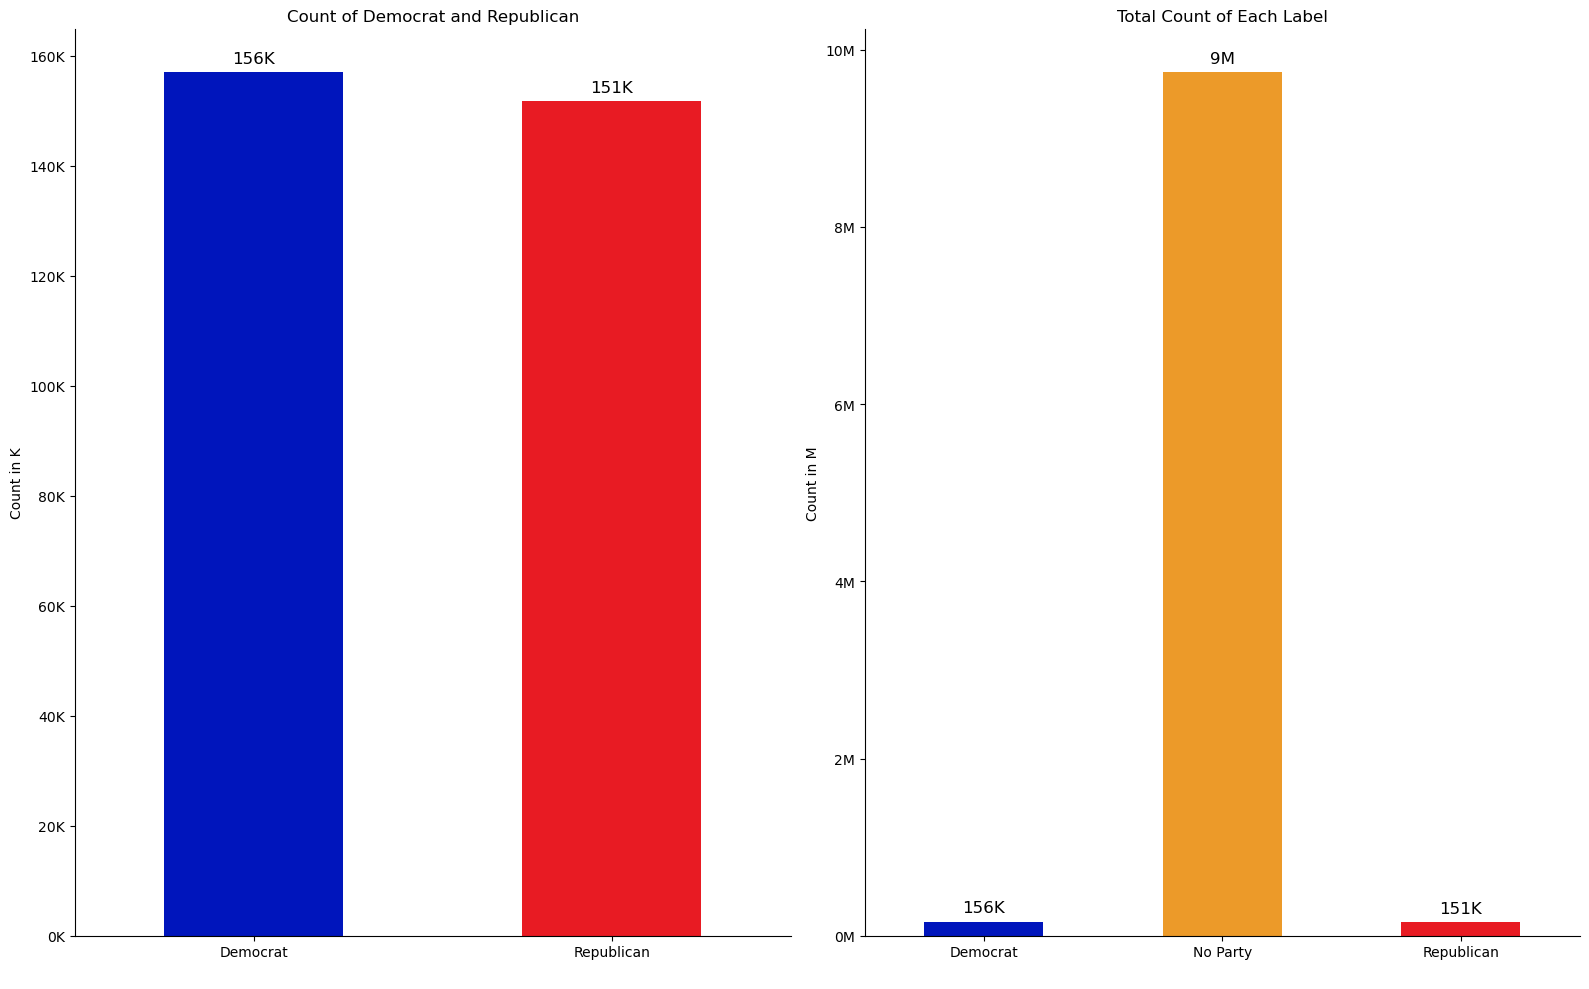

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# read data from parquet
df = pd.read_parquet('../data/Results_Reddit.parquet')

total_counts = df.groupby('Party')['party_count'].sum()
dr_counts = total_counts[total_counts.index.isin(['Democrat', 'Republican'])]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 10))

# First subplot for Democrat and Republican
dr_counts.plot(kind='bar', ax=axes[0], color=['#0015BC', '#E81B23'])
axes[0].set_title('Count of Democrat and Republican')
axes[0].set_xlabel(' ')
axes[0].set_ylabel('Count in K')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].tick_params(axis='x', rotation=0)
formatter = ticker.FuncFormatter(lambda x, pos: f'{int(x/1e3)}K')
axes[0].yaxis.set_major_formatter(formatter)

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()/1000)}K', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=12, color='black', xytext=(0, 10),
                     textcoords='offset points')


# Second subplot for all parties
total_counts.plot(kind='bar', ax=axes[1], color=['#0015BC', '#EC9A29', '#E81B23'])
axes[1].set_title('Total Count of Each Label')
axes[1].set_xlabel(' ')
axes[1].set_ylabel('Count in M')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].tick_params(axis='x', rotation=0)
formatter = ticker.FuncFormatter(lambda x, pos: f'{int(x/1e6)}M')
axes[1].yaxis.set_major_formatter(formatter)

for p in axes[1].patches:
    if p.get_height() >= 1e6:
        annotation = f'{int(p.get_height()/1e6)}M'
    else:
        annotation = f'{int(p.get_height()/1e3)}K'
    axes[1].annotate(annotation, (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=12, color='black', xytext=(0, 10),
                     textcoords='offset points')



# Show the plot
plt.tight_layout()
plt.show()